## Part 1

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import re
from nltk.corpus import stopwords
import nltk
import Stemmer
from tqdm.notebook import tqdm
nltk.download('stopwords', quiet=True)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import gc
from collections import Counter
from sklearn.metrics import confusion_matrix
from transformers import (
    AlbertTokenizer,
    AlbertForSequenceClassification,
    DataCollatorWithPadding
)
import torch

In [2]:
# Import small test dataset (for checking that the functions work)
url = "https://raw.githubusercontent.com/several27/FakeNewsCorpus/master/news_sample.csv"
df = pd.read_csv(url)

In [3]:
# Define regex patterns to use for tokenization:

# URLs
URL_RE = re.compile(
    r'https?://[^\s<>"{}|\\^`\[\]]+'  
    r'|www\.[^\s<>"{}|\\^`\[\]]+'     
    r'|\b[a-zA-Z0-9.-]+\.[a-z]{2,}'   
    r'(?:/[^\s]*)?',                   
    re.IGNORECASE
)

# Dates
DATE_RE = re.compile(
    r'\b\d{1,4}[-/\.]\d{1,2}[-/\.]\d{1,4}\b' 
    r'|\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*'  
    r'\.?\s+\d{1,2}(?:st|nd|rd|th)?'           
    r'(?:,?\s+\d{2,4})?\b'                      
    r'|\b\d{1,2}(?:st|nd|rd|th)?\s+'            
    r'(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*'
    r'(?:,?\s+\d{2,4})?\b',
    re.IGNORECASE
)
# Numbers
NUM_RE = re.compile(r'\b\d+\b')

# Words + special tokens.
TOKENS = re.compile(r'<[^>]+>|[a-z]+')

#non-english characters
NON_ENG = re.compile(r'[^\x00-\x7F]+')

# Get stopword list and stemmer.
stop_words = set(stopwords.words('english'))

stemmer = Stemmer.Stemmer('english')

In [20]:
def preprocessing(df, column):

    # Initialize vocabularies
    vocab_before  = set()
    vocab_no_stop = set()
    vocab_stemmed = set()
    tokenized = []
    
    non_eng_articles = 0
    total_url_count = 0
    total_date_count = 0
    tokens_num_count = 0
    empty_doc_count = 0

    # Go through each row (with progress bar)
    for text in tqdm(df.loc[:, column], desc="Preprocessing", mininterval=1.0):

        # Make all text lower case
        text = text.lower()

        # Switch out URLs, dates and numbers with special tokens
        text = URL_RE.sub(" <URL> ", text)
        text = DATE_RE.sub(" <DATE> ", text)
        text = NUM_RE.sub(" <NUM> ", text)

        tokens_url = text.count('<URL>')
        total_url_count += tokens_url
        tokens_date = text.count('<DATE>')
        total_date_count += tokens_date
        tokens_num = text.count('<NUM>')
        tokens_num_count += tokens_num

        # Make a list of tokens in the text
        tokens_before  = TOKENS.findall(text)

        tokens_non_eng = NON_ENG.findall(text)
        if len(tokens_non_eng) > len(tokens_before) * 0.30:
            non_eng_articles += 1


        # Remove stop words
        tokens_no_stop = [t for t in tokens_before if t not in stop_words]

        # Stem the tokens
        tokens_stemmed = stemmer.stemWords(tokens_no_stop)

        # Save the vocabularies at each step
        vocab_before.update(tokens_before)
        vocab_no_stop.update(tokens_no_stop)
        vocab_stemmed.update(tokens_stemmed)
        tokenized.append(tokens_stemmed)

        if tokenized == ['']:
            empty_doc_count += 1

    # Save results in the dataframe
    df["tokenized"] = tokenized



    # Print out relevant measures
    print(f'Vocabulary size before preprocessing: {len(vocab_before)}\n')
    for t, vocab in (('After removing stopwords', vocab_no_stop), ('After stemming', vocab_stemmed)):
        print(f'######## {t} ########')
        print(f"Vocabulary size: {len(vocab)}")
        print(f'Reduction rate: {1 - (len(vocab)/len(vocab_before))}\n')
    
    print(f'Number of Non-english articles: ~{non_eng_articles}')
    print(f"Number of url tokens: {total_url_count}")
    print(f'number of date tokens: {total_date_count}')
    print(f'number of number tokens: {tokens_num_count}')
    print(f'Number of articles with all text removed after preprocessing: {empty_doc_count}')
    return df

In [21]:
def data_split(X, y, train_frac = 0.8, test_frac = 0.1, val_frac = 0.1, stratify=None, seed=None):
    '''
    Splits the data into a training, testing and validation set. The size fraction of each set
    can be specified.

    Returns a tuple containing features (X) and targets (y) for all sets.
    '''

    # Split the dataset into training and other (test + val) set.
    X_train, X_other, y_train, y_other = train_test_split(X, y, test_size=(1-train_frac), stratify=stratify, random_state=seed)

    # Split other into test and val set.
    X_test, X_val, y_test, y_val = train_test_split(X_other, y_other, test_size=(val_frac/(test_frac+val_frac)), stratify=stratify, random_state=seed)

    return (X_train, X_test, X_val, y_train, y_test, y_val)

In [22]:
# Process small test set
df = preprocessing(df, 'content')


Preprocessing:   0%|          | 0/250 [00:00<?, ?it/s]

Vocabulary size before preprocessing: 15276

######## After removing stopwords ########
Vocabulary size: 15129
Reduction rate: 0.009622937941869636

######## After stemming ########
Vocabulary size: 9774
Reduction rate: 0.3601728201099764

Number of Non-english articles: ~0
Number of url tokens: 391
number of date tokens: 199
number of number tokens: 2414
Number of articles with all text removed after preprocessing: 0


In [9]:
# Download data from huggingface repositiory (we uploaded the data first).
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="MikkelPraestegaard/GDS_final_assignment",
    filename="subset_FakeNews.zip",
    repo_type="dataset",
)

In [10]:
# Read in the fakenews corpus
df1 = pd.read_csv(file_path)

# Remove the single row with NaN in content
df1 = df1.dropna(subset=['content'])

/tmp/ipykernel_148047/2196795015.py:2: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(file_path)


In [11]:
grouped_domain = df1[['type', 'domain']].groupby(by='domain')

c = 0
for i, v in grouped_domain:
    if len(v['type'].unique()) > 1:
        print('This domain has more then one type')
    else:
        c +=1

if c == len(grouped_domain):
    print('All domains have only 1 unique type attached to them')
else:
    print(f'{len(df1) - c} have more than 1 unique type')

del grouped_domain

All domains have only 1 unique type attached to them


In [12]:
# Remove rows with ambiguous True or False type (eg. satire). ~ is the not operation.
ambiguous = ['unknown', 'nan', 'political', 'clickbait', '2018-02-10 13:43:39.521661']
ambig_mask = ~df1['type'].isin(ambiguous)
df1 = df1.loc[ambig_mask, :]

# Create new column for True or Fake labels. True will be labeled 0/False and fake will be labels 1/True.
true_list = ['reliable']
df1['target'] = ~df1['type'].isin(true_list)

In [13]:
df1 = preprocessing(df1, 'content')

gc.collect()

Preprocessing:   0%|          | 0/729523 [00:00<?, ?it/s]

KeyboardInterrupt: 

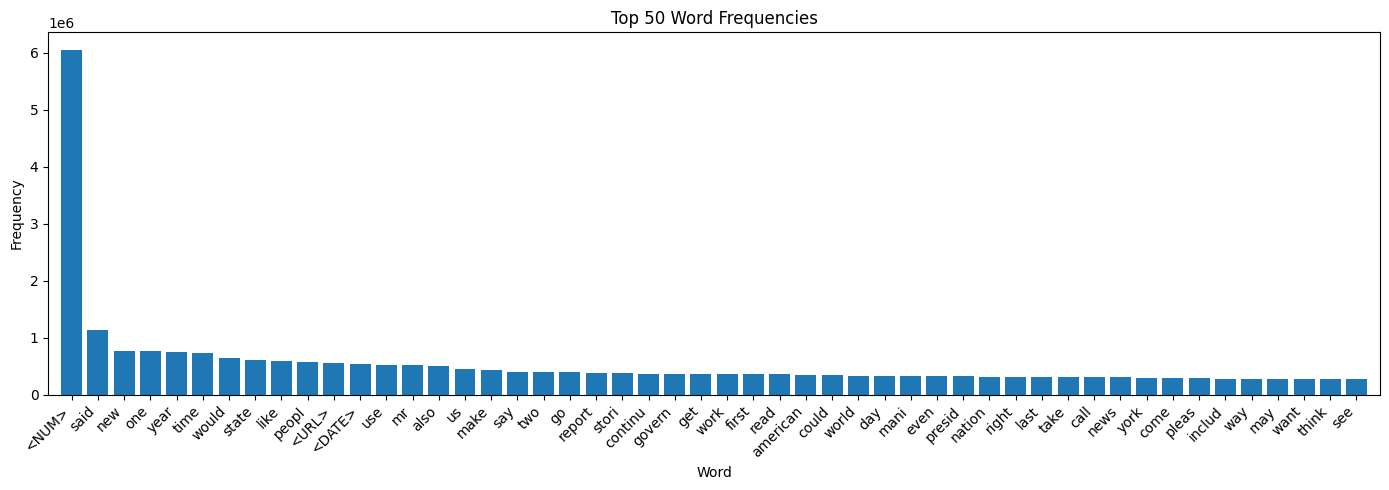

In [13]:
def wordcount(data):
    counter = Counter()

    for doc in data:
        if isinstance(doc, str):
            tokens = doc.split()
        else:
            tokens = doc
        
        counter.update(tokens)

    return counter


def visualize_top_words(
    data,              # iterable of token lists or strings
    top_n: int = 10_000,
    loglog: bool = True
):
    """
    data     : iterable of tokenized text (list of tokens per document) 
    top_n    : number of most frequent words to visualize
    loglog   : whether to use a log-log scale
    """
    label_limit = 100

    # Count words using Counter
    counter = wordcount(data)

    # Get the top_n words and their counts
    top_counts = counter.most_common(top_n)
    words, freqs = zip(*top_counts)  # separate words and counts

    # Plot
    plt.figure(figsize=(14, 5))

    if loglog:
        ranks = np.arange(1, len(freqs) + 1)
        plt.loglog(ranks, freqs)
        plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title("Word Frequency (Log-Log Scale)")
    else:
        if top_n <= label_limit:
            ranks = np.arange(len(words))
            plt.bar(words, freqs, align='center')
            plt.xticks(ranks, words, rotation=45, ha='right')
            plt.xlabel("Word")
        else:
            plt.plot(freqs)
            plt.xlabel("Rank")
        plt.ylabel("Frequency")
        plt.title(f"Top {len(freqs)} Word Frequencies")

    plt.margins(x=0.01)
    plt.tight_layout()
    plt.show()

    return

visualize_top_words(df1['tokenized'], 50, loglog=False)

In [14]:
def build_vectorizer(data):
    counter = wordcount(data)
    vocab = [word for word, _ in counter.most_common(10000)]

    vectorizer = CountVectorizer(
        vocabulary=vocab,
        tokenizer=lambda x: x,
        lowercase=False
    )
    
    return vectorizer

def transform_dataset(vectorizer, data):
    return vectorizer.transform(data)

In [ ]:
# If the preprocessed data has been saved to a file.
#df1 = pd.read_csv("Data/preprocessed.csv")

### The LIAR dataset - Binarization of labels

In [15]:
#loading of LIAR dataset

url = r'https://raw.githubusercontent.com/MikkelPraestegaard/GDS-final-assignment/refs/heads/main/Data/train.tsv'
liar_train = pd.read_csv(url, encoding= 'utf-8', sep = "\t", header = None)

url2 = r'https://raw.githubusercontent.com/MikkelPraestegaard/GDS-final-assignment/refs/heads/main/Data/valid.tsv'
liar_val = pd.read_csv(url2, encoding= 'utf-8', sep = "\t", header = None)

url3 = r'https://raw.githubusercontent.com/MikkelPraestegaard/GDS-final-assignment/refs/heads/main/Data/test.tsv'
liar_test = pd.read_csv(url3, encoding= 'utf-8', sep = "\t", header = None)

df2 = pd.concat([liar_train, liar_val, liar_test])


print(df2.info())

unique_liar, counts_liar = np.unique_counts(df2.iloc[:,1])
print(unique_liar)

# Remove rows with ambiguous True or False type (eg. satire), by keeping rows with non-ambiguous labels. ~ is the "not" operation.
ambiguous_liar = ['half-true'] #half tru is an ambiguous label
ambig_mask_liar = ~df2.iloc[:,1].isin(ambiguous_liar)
df2 = df2.loc[ambig_mask_liar, :]

# Create new column for True or Fake labels. True will be labeled 0/False and fake will be labels 1/True.
true_list = ['true','mostly-true']
df2['target'] = ~df2.iloc[:,1].isin(true_list)

#printing the binary label distribution
print(np.unique_counts(df2['target']))

df2 = preprocessing(df2, 2)

X_liar = df2['tokenized']
y_liar = df2['target']



<class 'pandas.core.frame.DataFrame'>
Index: 12791 entries, 0 to 1266
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       12791 non-null  object 
 1   1       12791 non-null  object 
 2   2       12791 non-null  object 
 3   3       12789 non-null  object 
 4   4       12789 non-null  object 
 5   5       9223 non-null   object 
 6   6       10040 non-null  object 
 7   7       12789 non-null  object 
 8   8       12789 non-null  float64
 9   9       12789 non-null  float64
 10  10      12789 non-null  float64
 11  11      12789 non-null  float64
 12  12      12789 non-null  float64
 13  13      12660 non-null  object 
dtypes: float64(5), object(9)
memory usage: 1.5+ MB
None
['barely-true' 'false' 'half-true' 'mostly-true' 'pants-fire' 'true']
UniqueCountsResult(values=array([False,  True]), counts=array([4507, 5657]))


Preprocessing:   0%|          | 0/10164 [00:00<?, ?it/s]

Vocabulary size before preprocessing: 11649

######## After removing stopwords ########
Vocabulary size: 11504
Reduction rate: 0.012447420379431695

######## After stemming ########
Vocabulary size: 7683
Reduction rate: 0.340458408447077

Number of Non-english articles: ~0


In [16]:
seed = 123

#preparation of already preprocessed, tokenized dataset

features = df1['tokenized']
labels = df1['target']

X_train, X_test, X_val, y_train, y_test, y_val = data_split(features, labels, seed=seed)

# Build ONLY on training data
vectorizer = build_vectorizer(features)

# Transform everything with SAME vocab
X_train = transform_dataset(vectorizer, X_train)
X_val   = transform_dataset(vectorizer, X_val)
X_test  = transform_dataset(vectorizer, X_test)
X_liar_logistic = transform_dataset(vectorizer, X_liar)

#printing label distribution
label_dists = {'Full Dataset': df1['target'].value_counts()/len(df1),
               'Training data': y_train.value_counts()/len(y_train),
               'Validation data': y_val.value_counts()/len(y_val),
               'Test data': y_test.value_counts()/len(y_test)}

label_dists = pd.DataFrame(label_dists)
label_dists

,Full Dataset,Training data,Validation data,Test data
target,,,,
True,0.700403,0.700623,0.702233,0.696814
False,0.299597,0.299377,0.297767,0.303186


In [17]:
# Logistic model
logistic = LogisticRegression(max_iter=2000, random_state=seed)

#fitting to FakeNews dataset
logistic.fit(X_train, y_train)

#testing on FakeNews validation set
preds_val = logistic.predict(X_val)
score_val = f1_score(y_val, preds_val)

# Testing on FakeNews testing set
preds_test = logistic.predict(X_test)
score_test = f1_score(y_test, preds_test)


gc.collect()


print(f'F1 score of logistic model on validation set: {score_val}')
print(f'F1 score of Logistic model on test set (FakeNews): {score_test}')

#testing on OOD LIAR dataset
preds_liar = logistic.predict(X_liar_logistic)
score_liar = f1_score(y_liar, preds_liar)
print(f'F1 score of Logistic model on test set (LIAR): {score_liar}')

F1 score of logistic model on validation set: 0.9575427697692981
F1 score of Logistic model on test set (FakeNews): 0.9548691747948599
F1 score of Logistic model on test set (LIAR): 0.715071785465815


## Evaluation

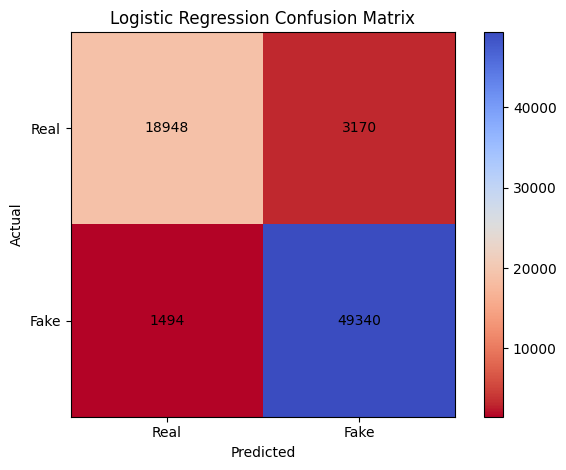

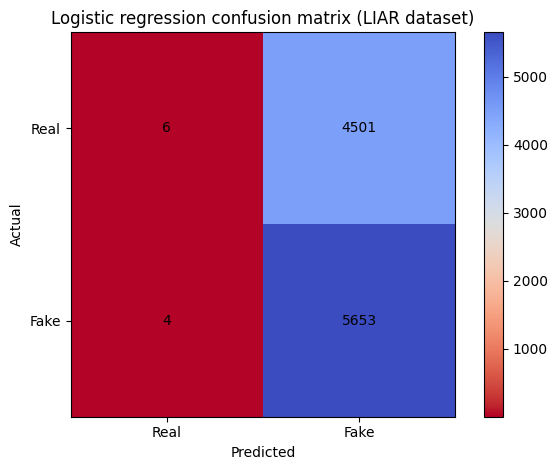

In [33]:


#confusion matrix
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm,cmap="coolwarm_r")
    plt.title(title)
    plt.colorbar()

    labels = np.unique(y_true)
    tick_marks = np.arange(len(labels))
    class_names = ["Real", "Fake"]  # or whatever you prefer
    
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

#logistic regression, fakenews dataset
plot_cm(y_test, preds_test, "Logistic Regression Confusion Matrix")

#logistic regression, liar dataset
plot_cm(y_liar, preds_liar, "Logistic regression confusion matrix (LIAR dataset)")


## Evaluation of fine-tuned ALBERT

In [19]:
from huggingface_hub import snapshot_download
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

seed =123

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



tokenizer = AutoTokenizer.from_pretrained("MikkelPraestegaard/FakeBERT")

albert = AlbertForSequenceClassification.from_pretrained("MikkelPraestegaard/FakeBERT", num_labels=2)

# Set model to evaluation mode
albert.eval()
albert.to(device)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

X = df1['content']
y = df1['target']

X_liar = df2.loc[:, 2]


X_train, X_test, X_val, y_train, y_test, y_val = data_split(X, y, seed=seed)

del X_train
del y_train
del df1
gc.collect()


8526

In [20]:
from datasets import Dataset
from torch.utils.data import DataLoader


def tokenize(data):
    try:
        return tokenizer(data['content'], truncation=True, padding=True, return_tensors="pt")
    except:
        return tokenizer(data["2"], truncation=True, padding=True, return_tensors="pt")
    
X_val = Dataset.from_pandas(X_val.to_frame())
X_val = X_val.map(tokenize, batched=True)

X_test = Dataset.from_pandas(X_test.to_frame())
X_test = X_test.map(tokenize, batched=True)

X_liar = Dataset.from_pandas(X_liar.to_frame())
X_liar = X_liar.map(tokenize, batched=True)

X_val = X_val.remove_columns(["content", "__index_level_0__"])
X_test = X_test.remove_columns(["content", "__index_level_0__"])
X_liar = X_liar.remove_columns(["2", "__index_level_0__"])

Map:   0%|          | 0/72953 [00:00<?, ? examples/s]

Map:   0%|          | 0/72952 [00:00<?, ? examples/s]

Map:   0%|          | 0/10164 [00:00<?, ? examples/s]

### ALBERT validation

In [21]:
eval_dataloader = DataLoader(X_val, batch_size=64, collate_fn=data_collator)

results_val = []
for batch in tqdm(eval_dataloader, desc='Predicting labels'):
    batch = {k: v.to(device) for k, v in batch.items()}

    with torch.inference_mode():
        preds = albert(**batch)

    preds = preds.logits
    preds = torch.argmax(preds, dim=-1)

    results_val.extend(preds.cpu().numpy())

validation_score = f1_score(y_val, results_val)
print(f"Validation score of ALBERT: {validation_score}")

Predicting labels:   0%|          | 0/1140 [00:00<?, ?it/s]

Validation score of ALBERT: 0.9958968061362728


### ALBERT testing (FakeNews)

In [22]:
test_dataloader = DataLoader(X_test, batch_size=64, collate_fn=data_collator)

results_test = []
for batch in tqdm(test_dataloader, desc='Predicting labels'):
    batch = {k: v.to(device) for k, v in batch.items()}

    with torch.inference_mode():
        preds = albert(**batch)

    preds = preds.logits
    preds = torch.argmax(preds, dim=-1)

    results_test.extend(preds.cpu().numpy())

test_score_fn = f1_score(y_test, results_test)
print(f"Test score of ALBERT (FakeNews): {test_score_fn}")

Predicting labels:   0%|          | 0/1140 [00:00<?, ?it/s]

Test score of ALBERT (FakeNews): 0.9956185161898774


### ALBERT test (LIAR)

In [23]:
liar_dataloader = DataLoader(X_liar, batch_size=64, collate_fn=data_collator)

results_liar = []
for batch in tqdm(liar_dataloader, desc='Predicting labels'):
    batch = {k: v.to(device) for k, v in batch.items()}

    with torch.inference_mode():
        preds = albert(**batch)

    preds = preds.logits
    preds = torch.argmax(preds, dim=-1)

    results_liar.extend(preds.cpu().numpy())

test_score_liar = f1_score(y_liar, results_liar)
print(f"Test score of ALBERT (FakeNews): {test_score_liar}")

Predicting labels:   0%|          | 0/159 [00:00<?, ?it/s]

Test score of ALBERT (FakeNews): 0.7126656472986749


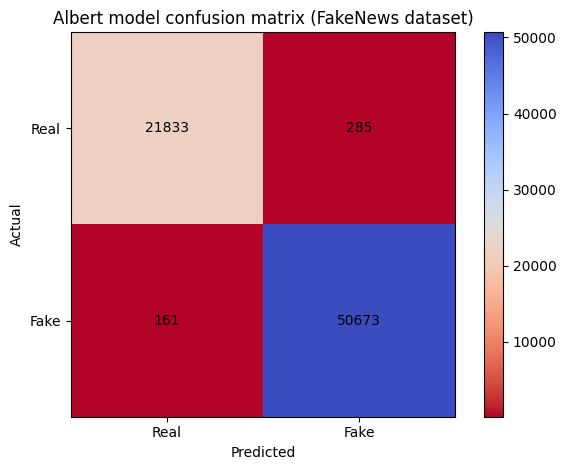

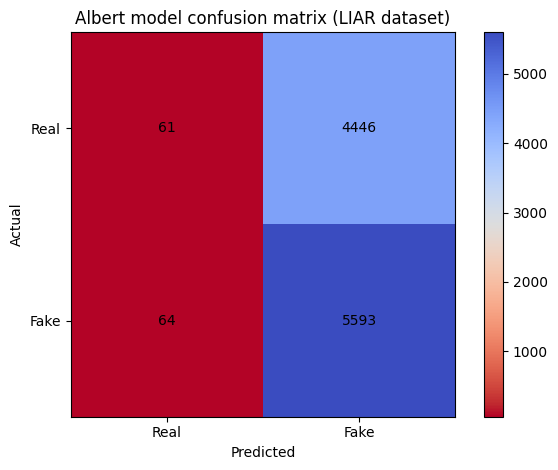

In [34]:
plot_cm(y_test,results_test,"Albert model confusion matrix (FakeNews dataset)")
plot_cm(y_liar,results_liar,"Albert model confusion matrix (LIAR dataset)")

### Table of scores

In [24]:
scores_dict = {'Logistic': [score_val, score_test, score_liar],
               'ALBERT': [validation_score, test_score_fn, test_score_liar]}

pd.DataFrame(scores_dict, index=['Validation', 'Test (FakeNews)', 'Test (LIAR)'])

,Logistic,ALBERT
Validation,0.957543,0.995897
Test (FakeNews),0.954869,0.995619
Test (LIAR),0.715072,0.712666
